In [1]:
from pathlib import Path
import datetime
import sys
import scipy.integrate
import random

%config InlineBackend.figure_format='retina'
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import pandas as pd


import matplotlib.font_manager as fm


mpl.rc('text', usetex=False)
#Code for using superscripts and subscripts
def get_super(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    super_s = "ᴬᴮᶜᴰᴱᶠᴳᴴᴵᴶᴷᴸᴹᴺᴼᴾQᴿˢᵀᵁⱽᵂˣʸᶻᵃᵇᶜᵈᵉᶠᵍʰᶦʲᵏˡᵐⁿᵒᵖ۹ʳˢᵗᵘᵛʷˣʸᶻ⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻⁼⁽⁾"
    res = x.maketrans(''.join(normal), ''.join(super_s))
    return x.translate(res)
def get_sub(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    sub_s = "ₐ₈CDₑբGₕᵢⱼₖₗₘₙₒₚQᵣₛₜᵤᵥwₓᵧZₐ♭꜀ᑯₑբ₉ₕᵢⱼₖₗₘₙₒₚ૧ᵣₛₜᵤᵥwₓᵧ₂₀₁₂₃₄₅₆₇₈₉₊₋₌₍₎"
    res = x.maketrans(''.join(normal), ''.join(sub_s))
    return x.translate(res)
#Checks to make sure you are in the right folder, if this is wrong reload
import os
print(os.getcwd())




C:\Users\jdnor\Documents\GitHub\SwearerCode


In [3]:
# Choose .csv data file and turn it into dataframe
colnames = ["wavenum" , "val"] #Defines the column tites for a csv without titles
# Edit the CSV Name here for your first file
file = pd.read_csv('240911_CuAl2O3_100ppm_JDN2_28_CO_60Min.csv', names = colnames) #,header=[0,1]) 
drifts_df = pd.DataFrame(file)
#This works for the CSV that is exported from the OMNIC software, where Wavenumber is the first column and the Units are the second column
#All CSVs imported together must have the same Wavenumber range! (Future code will be able to handle data with different ranges]
wavenum = drifts_df.iloc[:, 0]
#This step adds all the Data name, the data, and whether you want it to be included in the current plot with a true false statement. 
#This info is added as a list to a large list that compiles all your data
#The data name is used as the legend name for the data
datalist = [["Before",drifts_df.iloc[:, 1], True]]
#Change true to false for any one you want to exclude from a given plot.


#Copy this code and uncomment to import multiple spectra after the first one. 
#Important things to change are the file name, and variable name you want to use for the data
file = pd.read_csv('240911_CuAl2O3_100ppm_JDN2_28_CO_15Min.csv', names = colnames) 
df = pd.DataFrame(file)
drifts_df = df.iloc[:]
datalist.append(['15 min', drifts_df.iloc[:, 1], True])






In [11]:
# Subtracting Spectra
# This cell can be used to subtract spectra from each other. Select true to activate this cell.
#Data does not need to be displayed to be used as a subtraction! (It could be included as false)
if False:
    #Select which two data sets you want to use here. The minus is subtracted from the plus
    plus = "Data Name 1"
    minus =  "Data Name 2"
    for x in datalist:
        if x[0] == plus:
            plusdata = x[1]
        elif x[0] == minus:
            minusdata = x[1]
    subdata = plusdata - minusdata
    #The data here is appended to list of all data.
    datalist.append([plus + " - " + minus, subdata,True])
    #copy this code if you want to do multiple subtractions



In [4]:
#Collating the data in a version that can be used 

table_for_plot = pd.DataFrame({'Wavenumber': wavenum}) 
#Sets wavemnuber for display

for x in datalist:
    if x[2]:
        table_for_plot = table_for_plot.assign(temp = x[1])
        table_for_plot = table_for_plot.rename(columns = {"temp" : x[0]})
        print(x[0] + " : Yes")
    else:
        print(x[0] + " : No")
print(table_for_plot.columns)
#Loops through the list of data to add the data sets into a single dataframe and names it according to the string we set earlier.




0 min : Yes
15 min : Yes
30 min : Yes
45 min : Yes
60 min : Yes
Index(['Wavenumber', '0 min', '15 min', '30 min', '45 min', '60 min'], dtype='object')


In [8]:
# Aligns the data be zero all at one point. Important for comparing the shape and intensity of various peaks and doing integrations.
#If you would like to perform this  change baseline to True
baseline = True
if baseline:
 #aligning Data
#Pick a section that has all data flat, ideally with no peaks. You must put the lower number as wn1
    wn1 = 2150 # Start in wn
    wn2= 2160 # End in wn
    #Finds the location of that wavenumber in the index
    wn1_df = table_for_plot.iloc[(table_for_plot['Wavenumber']-wn1).abs().argsort()[:1]].index[0]
    wn2_df = table_for_plot.iloc[(table_for_plot['Wavenumber']-wn2).abs().argsort()[:1]].index[0]  
    #Takes the mean of that section in the region, and subtracts that value from the whole spectrum to shift it
    #Prints the difference for each spectrum to see whoi much it is changing
    for x in datalist:
        if x[2]:
            norm_diff = table_for_plot.loc[wn1_df:wn2_df,:].loc[:,x[0]].mean()
            print(x[0] + " : " + str(norm_diff))
            table_for_plot[x[0]] = table_for_plot[x[0]] - norm_diff
        


0 min : 0.001644329642857143
15 min : 0.0027439775952380957
30 min : 0.0017207986428571433
45 min : 0.0003178297831904761
60 min : -0.0007526910476190476


[-0.006, 0.001, 0.007, 0.014, 0.02, 0.027, 0.033, 0.04]


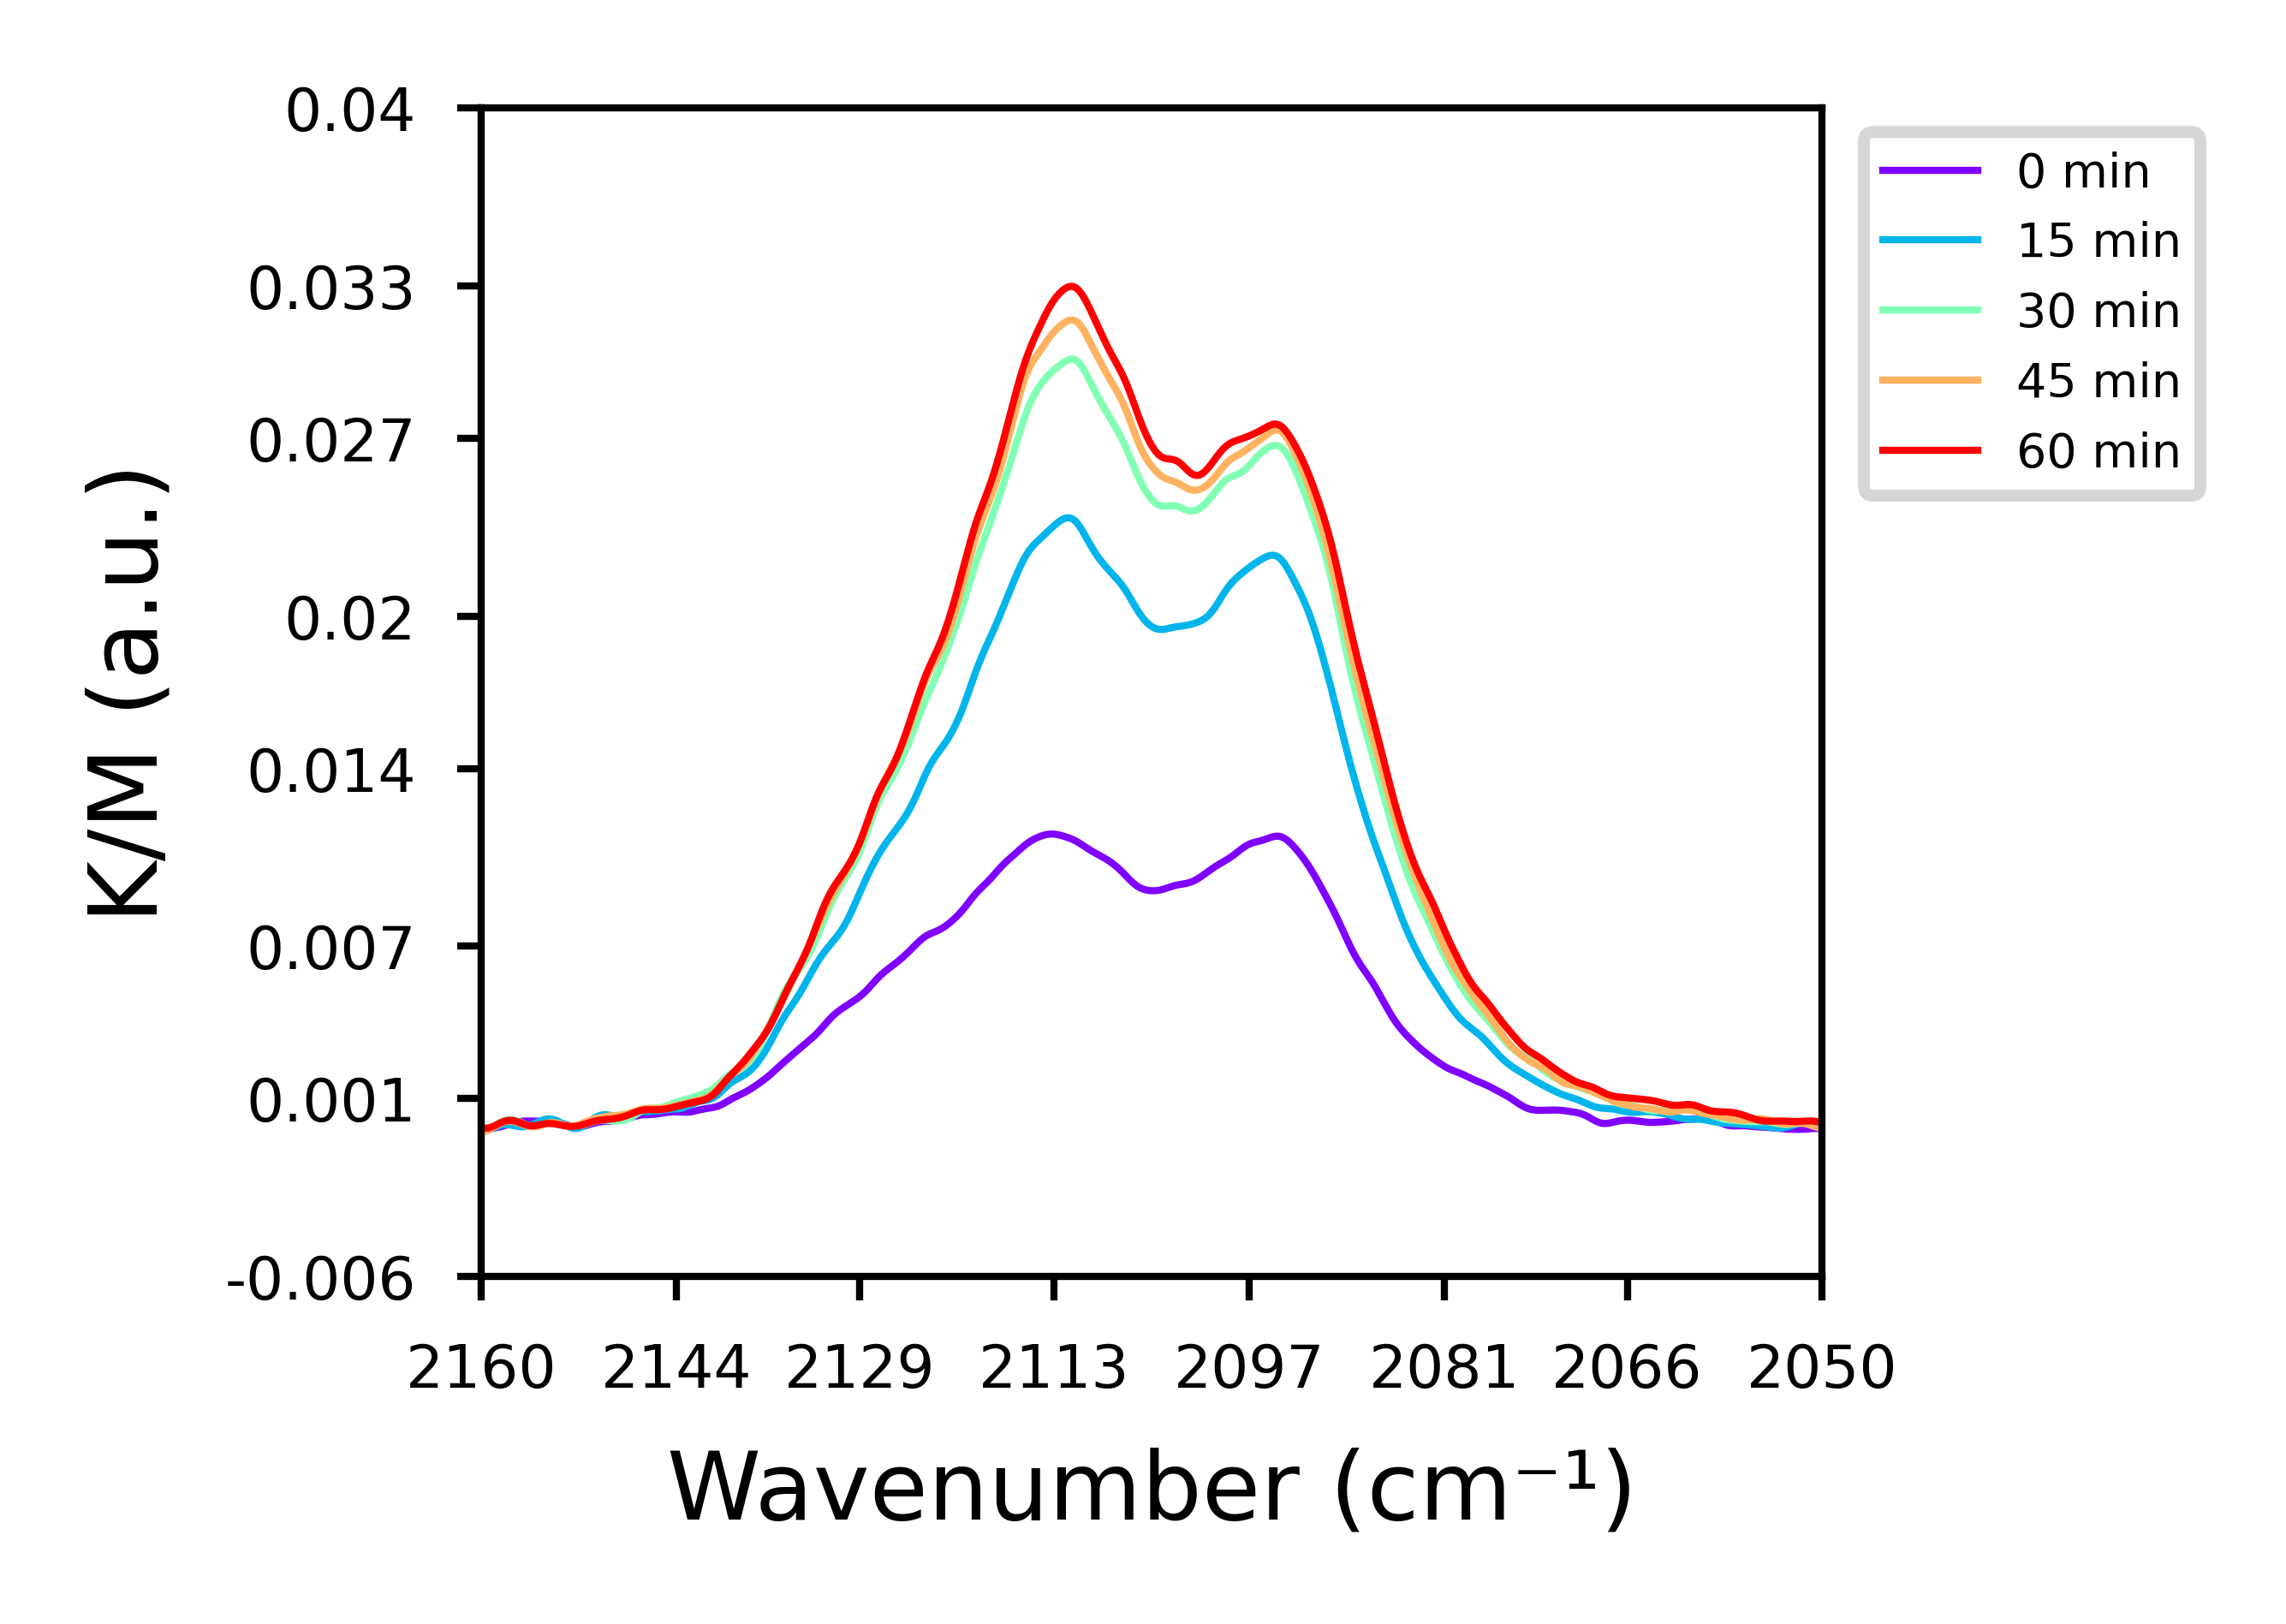

In [9]:
#The plotting 
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
font_size = 1

cmap = mpl.colormaps['rainbow']

#Font settings to make it processable in illustrator don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = '240911_CuAl2O3_100ppm_JDN2_28_CO_ads'

#Generation of the figure, change the figsize for the application you want (poster paper etc)
fig,ax = plt.subplots(dpi=250*(1/font_size))
drift = table_for_plot.set_index('Wavenumber').plot(figsize=(3, 2), linewidth = 0.6*font_size, ax = ax,cmap = cmap)
#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis
plt.gca().invert_xaxis()


#Following settings can be changed based on what you want your chart to look like
# Axis labels
drift.set_xlabel("Wavenumber (cm" + get_super("-1") + ")", fontsize = 8*font_size,)
drift.set_ylabel("K/M (a.u.)", fontsize = 8*font_size)

#Set axis line widths
for axis in ['bottom','left']:
    drift.spines[axis].set_linewidth(0.6*font_size)
    drift.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    drift.spines[axis].set_visible(True)
    drift.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
drift.tick_params(width = 0.6*font_size, length = 2*font_size)
drift.tick_params(axis='both', which='minor', labelsize=8)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
drift.yaxis.set_ticks_position('left')
drift.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 2160 #High Range
xlow = 2050 #Low Range
xpoints = 8 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
if xdigits <= 0:
    xlabels = [int(num) for num in xlabels]
drift.set_xticks(xlabels)
drift.set_xticklabels(xlabels)
drift.set_xlim(xhigh, xlow)

#Adjusting range and tick frequency of y axis
yhigh = 0.04 #High Range
ylow = -.006 #Low Range
ypoints = 8 #How many points you want on your axis
ydigits = 3 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]
print (ylabels)
drift.set_yticks(ylabels)
drift.set_yticklabels(ylabels)
drift.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#drift.set_yticks([])
#drift.set_yticklabels([])
#drift.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
drift.legend(fontsize = 4*font_size, loc = "upper right", title_fontsize =4*font_size, bbox_to_anchor=(1.3, 1))
plt.tight_layout()


#Saving and plotting of figure

plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()


In [7]:
#Integrate a section: Take start and dend WN of what you want to integrate
wn1 = 1850 # Start in wn
wn2= 2050 # End in wn
wn1_df = table_for_plot.iloc[(table_for_plot['Wavenumber']-wn1).abs().argsort()[:1]].index[0]
wn2_df = table_for_plot.iloc[(table_for_plot['Wavenumber']-wn2).abs().argsort()[:1]].index[0]  
table_width = int(table_for_plot.size/len(table_for_plot))
for x in datalist:
    if x[2]:
        norm_diff = table_for_plot.loc[wn1_df:wn2_df,:].loc[:,["Wavenumber",x[0]]]
        #print(norm_diff)
        integrated_val = scipy.integrate.trapezoid(norm_diff.loc[:,x[0]], norm_diff.loc[:,"Wavenumber"])
        #table_for_plot[x[0]] = table_for_plot[x[0]] - norm_diff
        print(x[0] + " : " + str(integrated_val))
        
display(wn1_df)
display(wn2_df)

0MinCODose : -0.023406159576795


766

1009